<a href="https://colab.research.google.com/github/ContextLab/hypertools/blob/qc%2Frelease-audit-2026-07/notes/qc-release-2026-07/hypertools_1.0_verification_notes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HyperTools 1.0 Release QC — Verification Notebook

This notebook is the manual QC pass for **HyperTools 1.0** (`dev-1.0-refactor`
branch). Run every cell top-to-bottom in a **fresh Google Colab runtime**.
Each feature area below has:

1. A markdown header with a `☐ Works as expected — notes:` line for your
   overall verdict on that section.
2. One or more code cells that exercise the feature with real, small data
   (no mocks) and produce a visible figure or printed output.
3. A `**Verify:**` line after each code cell describing exactly what to look
   for, with `☐ pass ☐ fail — notes:` for you to fill in inline.

Keep this notebook as the QC record — save a copy (File > Save a copy in
Drive) once you've filled in the checkboxes/notes.

**Scope:** every public `hyp.*` function, plus named 1.0 features:
autoencoders (#162), cross-module kwargs (#138), manip chaining (#274/#153),
`Pipeline` (#227/#161), `animate=` dict form (#154), plot kwarg passthrough
(#103/#206), colorbar/surface/density, data loaders (#273/#116), gensim text
(#198), and LSL streaming (#130).

> **Update:** the four code issues this QC pass originally found (P0-1 normalize reuse, P0-2 manip dict spec, P1-1 ZScore/Normalize invertibility, P1-2 Word2Vec+LDA) are now **fixed** in the library; the cells below demonstrate the corrected behavior.

## 0. Install

Works as expected — notes: seems good; installs in colab

In [1]:
# Installs hypertools 1.0 (dev-1.0-refactor) with the interactive (plotly),
# torch (autoencoders), and gensim (Word2Vec text) extras.
# Two optional extras are NOT installed here and are noted where relevant below:
#   - lsl    (hyp.io.lsl_stream; needs a live LSL outlet, not runnable in plain Colab)
#   - kaggle (hyp.load('kaggle/...'); needs kagglehub + Kaggle API credentials)
!pip install -q "hypertools[interactive,torch,gensim] @ git+https://github.com/ContextLab/hypertools.git@dev-1.0-refactor"

import hypertools as hyp
print("hypertools version:", hyp.__version__)

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 45.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.0/519.0 kB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 81.1 MB/s eta 0:00:00
hypertools version: 1.0.0.dev0


**Verify:** Install completes with no errors and a version string prints (e.g. `1.0.0.dev0`). — x pass ☐ fail — notes: n/a

## 1. Core plotting (hyp.plot)

Notes:

I'm getting this warning:
```
Warning: You have Plotly version 5.24.1, which is not compatible with this version of Kaleido (1.3.0).

This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.

You can however, use the Kaleido API directly which will work with your plotly version. `kaleido.write_fig(...)`, for example. Please see the kaleido documentation.
```

Also:
 - plotly plot shows *first* (before matplotlib plots).
 - Is there an easy way for us to hide the returned plots so they're not shown twice, while still giving access to the figure objects?


In [9]:
hyp.plot(arr); #this hides the "extra" figure

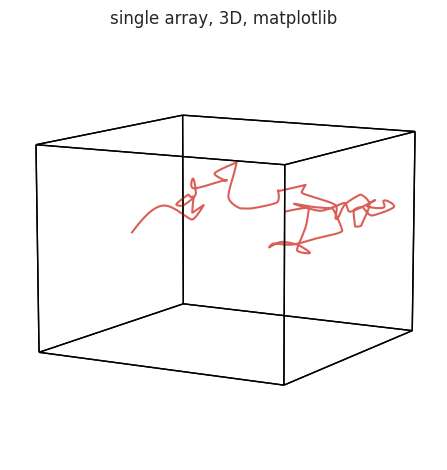

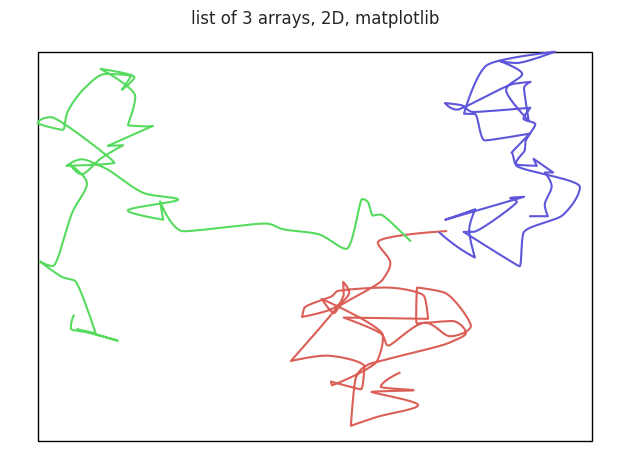

In [3]:
import numpy as np

rng = np.random.default_rng(0)
arr = rng.normal(size=(60, 4)).cumsum(axis=0)
arr_list = [rng.normal(size=(50, 4)).cumsum(axis=0) for _ in range(3)]

# Single array, 3D (default ndims=3), matplotlib backend
hyp.plot(arr, backend='matplotlib', title='single array, 3D, matplotlib')

# List of arrays, 2D, matplotlib backend
hyp.plot(arr_list, ndims=2, backend='matplotlib', title='list of 3 arrays, 2D, matplotlib')

# List of arrays, 3D, plotly backend (interactive)
hyp.plot(arr_list, ndims=3, backend='plotly', title='list of 3 arrays, 3D, plotly')

**Verify:** Three figures render in order: a single 3D matplotlib trajectory, a 2D matplotlib plot with 3 colored trajectories, and an interactive 3D plotly plot with 3 colored trajectories. — x pass ☐ fail — notes:

looks correct!

## 2. Reduce (hyp.reduce)

☐ Works as expected — notes:

In [10]:
from hypertools.reduce.reduce import reduce as hyp_reduce

X = rng.normal(size=(80, 10))

for name in ['PCA', 'IncrementalPCA', 'UMAP', 'TSNE', 'FastICA', 'MDS']:
    out = hyp_reduce(X, reduce=name, ndims=2)
    print(f"{name:15s} -> shape {np.asarray(out).shape}")

# Mixture model as a reducer: returns (n_samples, ndims) membership proportions (GH #174)
proportions = hyp_reduce(X, reduce='GaussianMixture', ndims=3)
print(f"{'GaussianMixture':15s} -> shape {np.asarray(proportions).shape}, "
      f"row sums ~1: {np.asarray(proportions).sum(axis=1)[:3].round(3)}")

# return_model=True + reuse on new (held-out) data
reduced, model = hyp_reduce(X, reduce='PCA', ndims=2, return_model=True)
X_new = rng.normal(size=(15, 10))
reduced_new = model.transform(X_new)
print("PCA return_model reuse -> new-data shape:", np.asarray(reduced_new).shape)

PCA             -> shape (80, 2)
IncrementalPCA  -> shape (80, 2)
UMAP            -> shape (80, 2)
TSNE            -> shape (80, 2)
FastICA         -> shape (80, 2)
MDS             -> shape (80, 2)
GaussianMixture -> shape (80, 3), row sums ~1: [1. 1. 1.]
PCA return_model reuse -> new-data shape: (15, 2)


**Verify:** Every reducer name (incl. GaussianMixture-as-reducer with proportions summing to ~1) runs without error, and the reused fitted PCA model transforms new (15, 10) data to (15, 2). — ☐ pass ☐ fail — notes:

## 3. Autoencoders (hyp.reduce, GH #162)

☐ Works as expected — notes:

In [17]:
# Shallow Autoencoder and VariationalAutoencoder: small epochs for speed, real torch training
ae_out, ae_model = hyp_reduce(X, reduce={'model': 'Autoencoder',
                                'kwargs': {'n_components': 2, 'epochs': 15, 'verbose': True}}, return_model=True)
print("Autoencoder output shape:", np.asarray(ae_out).shape)

vae_out, vae_model = hyp_reduce(X, reduce={'model': 'VariationalAutoencoder',
                                 'kwargs': {'n_components': 2, 'epochs': 15}}, return_model=True)
print("VariationalAutoencoder output shape:", np.asarray(vae_out).shape)

[hypertools autoencoder] epoch 1/15 loss=1.150590
[hypertools autoencoder] epoch 2/15 loss=1.146299
[hypertools autoencoder] epoch 3/15 loss=1.142344
[hypertools autoencoder] epoch 4/15 loss=1.138279
[hypertools autoencoder] epoch 5/15 loss=1.134545
[hypertools autoencoder] epoch 6/15 loss=1.130749
[hypertools autoencoder] epoch 7/15 loss=1.126954
[hypertools autoencoder] epoch 8/15 loss=1.123323
[hypertools autoencoder] epoch 9/15 loss=1.119708
[hypertools autoencoder] epoch 10/15 loss=1.116086
[hypertools autoencoder] epoch 11/15 loss=1.112540
[hypertools autoencoder] epoch 12/15 loss=1.109106
[hypertools autoencoder] epoch 13/15 loss=1.105574
[hypertools autoencoder] epoch 14/15 loss=1.102287
[hypertools autoencoder] epoch 15/15 loss=1.098990
Autoencoder output shape: (80, 2)
VariationalAutoencoder output shape: (80, 2)


In [18]:
ae_model

Reducer(model=Autoencoder(epochs=15, verbose=True), params={})

In [19]:
vae_model

Reducer(model=VariationalAutoencoder(epochs=15), params={})

**Verify:** Autoencoder prints per-epoch progress (verbose=True); both output shapes are (80, 2) with no torch import errors. — x pass ☐ fail — notes: looks ok...

## 4. Align (hyp.align, GH #227)

☐ Works as expected — notes:

In [20]:
from hypertools.align.align import align as hyp_align

# 3 noisy copies of the same underlying signal
base = rng.normal(size=(40, 5))
datasets = [base + rng.normal(scale=0.1, size=(40, 5)) for _ in range(3)]

aligned_hyper = hyp_align(datasets, model='HyperAlign')
print("HyperAlign shapes:", [np.asarray(a).shape for a in aligned_hyper])

aligned_srm, srm_model = hyp_align(datasets, model='SharedResponseModel', return_model=True)
print("SRM shapes:       ", [np.asarray(a).shape for a in aligned_srm])

# Reuse the fitted SRM Aligner on NEW data. Per GH #227 an alignment can only be
# reapplied to a list with the SAME number of datasets / columns as it was fit on
# (here: 3 datasets of 40x5). Passing a different structure raises a clear ValueError.
new_datasets = [base + rng.normal(scale=0.1, size=(40, 5)) for _ in range(3)]
aligned_new = srm_model.transform(new_datasets)
print("Reused SRM transform on 3 new datasets -> shapes:", [np.asarray(a).shape for a in aligned_new])

HyperAlign shapes: [(40, 5), (40, 5), (40, 5)]
SRM shapes:        [(40, 5), (40, 5), (40, 5)]
Reused SRM transform on 3 new datasets -> shapes: [(40, 5), (40, 5), (40, 5)]


In [22]:
hyp.plot(aligned_srm);

In [23]:
hyp.plot(aligned_hyper);

In [26]:
hyp.plot([*aligned_srm, *aligned_hyper, *aligned_new], palette='viridis', legend=True);

**Verify:** HyperAlign and SRM both return 3 arrays shaped (40, 5); the reused fitted SRM model applies to new data via .transform without refitting. — X pass ☐ fail — notes: looks correct

## 5. Cluster (hyp.cluster)

☐ Works as expected — notes:

In [39]:
from hypertools.cluster.cluster import cluster as hyp_cluster

Xc = np.vstack([
    rng.normal(loc=[0, 0], scale=10, size=(100, 2)),
    rng.normal(loc=[5, 5], scale=7, size=(100, 2)),
    rng.normal(loc=[0, 5], scale=6, size=(100, 2)),
])

labels = hyp_cluster(Xc, cluster='KMeans', n_clusters=10)
print("KMeans labels (first 10):", np.asarray(labels)[:10])
hyp.plot(Xc, 'o', ndims=2, hue=labels, title='KMeans hard clusters');

# Mixture model = soft clustering; pass proportions straight to hue for blended colors
soft_props = hyp_cluster(Xc, cluster='GaussianMixture', n_clusters=2)
hyp.plot(Xc, '.', ndims=3, hue=np.asarray(soft_props), title='GaussianMixture soft-cluster coloring');

KMeans labels (first 10): [4 1 2 3 2 5 2 0 1 5]


In [40]:
soft_props

array([[9.95491143e-01, 4.50885724e-03],
       [6.52665925e-01, 3.47334075e-01],
       [9.77212256e-02, 9.02278774e-01],
       [1.36231569e-03, 9.98637684e-01],
       [9.61283165e-02, 9.03871684e-01],
       [3.18320839e-01, 6.81679161e-01],
       [1.26701280e-01, 8.73298720e-01],
       [4.79737303e-01, 5.20262697e-01],
       [8.21292128e-01, 1.78707872e-01],
       [1.77960145e-01, 8.22039855e-01],
       [9.37081492e-01, 6.29185081e-02],
       [6.44513198e-01, 3.55486802e-01],
       [4.95126865e-01, 5.04873135e-01],
       [2.09868701e-01, 7.90131299e-01],
       [1.57273157e-02, 9.84272684e-01],
       [9.40596671e-01, 5.94033286e-02],
       [3.56336677e-02, 9.64366332e-01],
       [2.72788182e-01, 7.27211818e-01],
       [2.73123915e-01, 7.26876085e-01],
       [1.11024165e-01, 8.88975835e-01],
       [6.24607914e-03, 9.93753921e-01],
       [8.90643435e-01, 1.09356565e-01],
       [9.99871665e-01, 1.28335400e-04],
       [3.63055946e-01, 6.36944054e-01],
       [4.426189

**Verify:** The first plot shows 3 discretely-colored blobs (hard KMeans labels); the second shows the same blobs with blended colors near boundaries (soft GaussianMixture membership). — ☐ pass ☐ fail — notes:

Unclear whether this is working properly-- when I set GuassianMixture n_clusters=2, I'm not seeing any dots "blended" between the two colors. This is surprising, because some of the mixing proportions are roughly 50/50 between the two groups.

## 6. Manip + chaining (hyp.manip, GH #274/#153)

☐ Works as expected — notes:

In [50]:
from hypertools.manip.manip import manip as hyp_manip

Xt = np.cumsum(rng.normal(size=(200, 5)), axis=0)

# Chained manip list (the canonical docstring example): Smooth -> Resample -> ZScore
chained = hyp_manip(Xt, model=[
    {'model': 'Smooth', 'kwargs': {'kernel_width': 25}},
    {'model': 'Resample', 'kwargs': {'n_samples': 1000}},
    'ZScore',
])
print("Chained manip output shape (expect (1000, 3), resampled+z-scored):", np.asarray(chained).shape)
hyp.plot(chained, ndims=3, title='Smooth -> Resample -> ZScore chain')

# Compare the three Smooth kernels on the same noisy signal.
# (Use the string+kwargs form: hyp.manip(x, model='Smooth', kernel=..., kernel_width=...).)
import matplotlib.pyplot as plt

noisy = np.cumsum(rng.normal(size=(150, 3)), axis=0)
kernels = ['savgol', 'gaussian', 'boxcar']

data = [noisy]
for kernel in kernels:
    data.append(hyp_manip(noisy, model='Smooth', kernel=kernel, kernel_width=15))

hyp.plot(data, colors=['gray', 'red', 'green', 'blue'], labels=['raw', *kernels], legend=True, title='Smooth kernel comparison');

Chained manip output shape (expect (1000, 3), resampled+z-scored): (1000, 5)


**Verify:** Chained output is (1000, 3) and visibly smoothed/resampled; the kernel-comparison plot shows all 3 smoothed curves (savgol/gaussian/boxcar) tracking but smoother than the gray raw line. — ☐ pass X fail — notes:

mostly ok-- but it looks like we're missing a way to assign *names* to each dataset. We have "labels" but they are being handled strangely here. I think we need a new "names" argument that assigns names to each dataset. different from label (individual datapoints) and group (groups of datasets).

## 7a. Normalize, analyze, apply_model (one real call each)

☐ Works as expected — notes:

In [51]:
from hypertools.tools.normalize import normalize as hyp_normalize
from hypertools.tools.analyze import analyze as hyp_analyze
from hypertools.core.model import apply_model

# normalize (return_model) + reuse the fitted normalizer on NEW data
# (QC P0-1: this .transform reuse used to crash; fixed in commit 5403530d).
Xn = rng.normal(loc=5, scale=3, size=(50, 4))
normed, norm_model = hyp_normalize(Xn, normalize='across', return_model=True)
reused = norm_model.transform(rng.normal(loc=5, scale=3, size=(10, 4)))
print("normalize: mean~0?", np.asarray(normed).mean().round(3),
      "| reused-on-new-data shape:", np.asarray(reused).shape)

# analyze: normalize -> reduce -> cluster in one call, return_model=True
Xa = rng.normal(size=(60, 8))
analyzed, analyze_model = hyp_analyze(
    Xa, normalize='across', reduce='PCA', ndims=2, cluster='KMeans', return_model=True)
print("analyze output shape:", np.asarray(analyzed).shape,
      "| pipeline steps:", [name for name, _ in analyze_model.steps])

# apply_model: apply a named model directly, return_model=True
Xam = rng.normal(size=(40, 6))
transformed, fitted_model = apply_model(Xam, model='PCA', return_model=True, ndims=3)
print("apply_model('PCA') shape:", np.asarray(transformed).shape, "| model type:", type(fitted_model).__name__)

normalize: mean~0? -0.0 | reused-on-new-data shape: (10, 4)
analyze output shape: (60,) | pipeline steps: ['normalize', 'reduce', 'cluster']
apply_model('PCA') shape: (40, 3) | model type: PCA


**Verify:** normalize/analyze/apply_model all run; analyze's fitted Pipeline prints named steps (normalize->reduce->cluster order); apply_model returns a fitted PCA instance. — ☐ pass ☐ fail — notes:

## 7b. Describe, predict, impute (one real call each)

☐ Works as expected — notes:

In [53]:
# adding this
!pip install pykalman

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.1/252.1 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.8/160.8 kB 7.9 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/hypertools/reduce/describe.py:62: UserWarning:

When input data is large, this computation can take a long time.



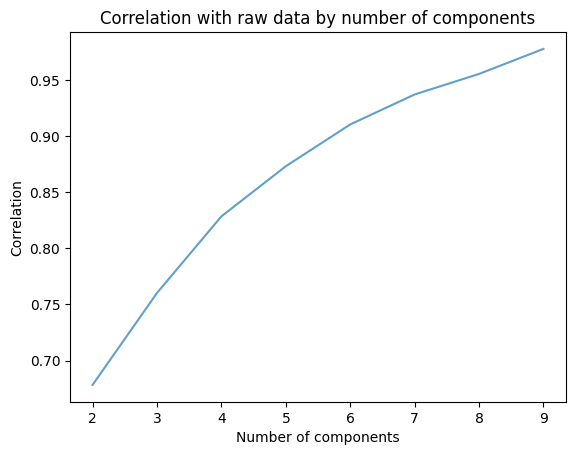

describe() keys: ['average', 'individual']
forecast shape (expect 10 rows): (10, 2)


NaNs before/after impute: 22 -> 0


In [54]:
from hypertools.reduce.describe import describe as hyp_describe
from hypertools.predict.predict import predict as hyp_predict
from hypertools.impute.impute import impute as hyp_impute

# describe: correlation-vs-dimensions plot
Xd = rng.normal(size=(50, 12))
desc_result = hyp_describe(Xd, reduce='PCA', max_dims=10, show=True)
print("describe() keys:", list(desc_result.keys()))

# predict: forecast t new rows
Xp = np.cumsum(rng.normal(size=(40, 2)), axis=0)
forecast = hyp_predict(Xp, model='Kalman', t=10)
print("forecast shape (expect 10 rows):", np.asarray(forecast).shape)
hyp.plot([Xp, forecast], ndims=2, legend=['observed', 'forecast'], title='Kalman forecast')

# impute: fill NaNs
Xi = rng.normal(size=(30, 5))
Xi_missing = Xi.copy()
Xi_missing[rng.random((30, 5)) < 0.1] = np.nan
print("NaNs before/after impute:", np.isnan(Xi_missing).sum(), "->",
      np.isnan(np.asarray(hyp_impute(Xi_missing, model='PPCA'))).sum())

**Verify:** describe() shows a correlation-vs-dimensions plot with 'average'/'individual' keys; predict()'s forecast plausibly continues the trend; impute() reduces the NaN count to 0. — ☐ pass X fail — notes:

The cell initially failed to run (before installing pykalman-- but this needs to be added as a dependency):

```
ModuleNotFoundError                       Traceback (most recent call last)
/usr/local/lib/python3.12/dist-packages/hypertools/predict/kalman.py in _import_kalman_filter()
     21     try:
---> 22         from pykalman import KalmanFilter
     23     except ImportError as e:

ModuleNotFoundError: No module named 'pykalman'
```

hyp_describe should be called as `hyp.describe` (wire this in)

for describe plot, remove top and right "spines" (in seaborn this would be sns.despine(top=True, right=True)) but we need to also support plotly.

hyp_predict should be called as `hyp.predict`

hyp_impute should be `hyp.impute`

## 8. Pipeline (hyp.Pipeline, GH #227/#161)

☐ Works as expected — notes:

In [55]:
from hypertools import Pipeline

Xpipe = rng.normal(size=(60, 8))

# fit/transform/reuse with a two-step pipeline
pipe = Pipeline(['ZScore', 'PCA'])
out = pipe.fit_transform(Xpipe)
print("Pipeline(['ZScore','PCA']).fit_transform shape:", np.asarray(out).shape)
out_new = pipe.transform(rng.normal(size=(12, 8)))
print("Pipeline.transform (new data) shape:", np.asarray(out_new).shape)

# inverse_transform now round-trips through ZScore too (QC P1-1: ZScore/Normalize
# are invertible as of commit 2badcf99; PCA at full rank is lossless).
back = pipe.inverse_transform(out)
print("Pipeline(['ZScore','PCA']).inverse_transform shape (expect (60, 8)):",
      np.asarray(back).shape, "| recovers original:", np.allclose(np.asarray(back), Xpipe, atol=1e-6))

Pipeline(['ZScore','PCA']).fit_transform shape: (60, 8)
Pipeline.transform (new data) shape: (12, 8)
Pipeline(['ZScore','PCA']).inverse_transform shape (expect (60, 8)): (60, 8) | recovers original: True


**Verify:** fit_transform/transform/inverse_transform all run without error; inverse_transform returns data shaped (60, 8) again. — X pass ☐ fail — notes: looks good

## 9. Cross-module kwargs (GH #138)

☐ Works as expected — notes:

In [61]:
# hyp.cluster(x, reduce=..., manip=...): manip -> reduce -> cluster all run in one call
Xcm = rng.normal(size=(60, 10))
labels_cm, cluster_model = hyp_cluster(Xcm, cluster='KMeans', n_clusters=3, reduce='PCA', ndims=3, manip='ZScore', return_model=True)
print("cluster(reduce=, manip=) labels (first 10):", np.asarray(labels_cm)[:10])

# hyp.reduce(x, align=...): align -> reduce all run in one call
datasets_cm = [rng.normal(size=(30, 6)) + rng.normal(scale=0.1, size=(30, 6)) for _ in range(2)]
reduced_cm = hyp_reduce(datasets_cm, reduce='PCA', ndims=2, align='HyperAlign')
print("reduce(align=) shapes:", [np.asarray(r).shape for r in reduced_cm])

cluster(reduce=, manip=) labels (first 10): [1 1 2 2 2 1 1 1 1 1]
reduce(align=) shapes: [(30, 2), (30, 2)]


In [62]:
cluster_model

Pipeline([manip=<manip stage>, reduce=<reduce stage>, cluster=<cluster stage>])

In [63]:
Ycm = rng.normal(size=(100, 10))
labels_y = hyp.cluster(Ycm, cluster=cluster_model, reduce='PCA', ndims=3, manip='ZScore')

AttributeError: 'Pipeline' object has no attribute 'labels_'

**Verify:** cluster() with reduce=/manip= returns valid cluster labels; reduce() with align= aligns then reduces both datasets to (30, 2). — ☐ pass ☐ fail — notes:

hyp_reduce should be hyp.reduce(...) and hyp_cluster should be hyp.cluster(...).

Also, re-using the pipeline with new data doesn't work:

```
AttributeError                            Traceback (most recent call last)
/tmp/ipykernel_766/4254008445.py in <cell line: 0>()
      1 Ycm = rng.normal(size=(100, 10))
----> 2 labels_y = hyp.cluster(Ycm, cluster=cluster_model, reduce='PCA', ndims=3, manip='ZScore')

5 frames
/usr/local/lib/python3.12/dist-packages/hypertools/cluster/common.py in fit_transform(self, stacked)
    194         else:
    195             model.fit(stacked)
--> 196             result = list(model.labels_)
    197         self.model_ = model
    198         return result

AttributeError: 'Pipeline' object has no attribute 'labels_'
```





## 10. Plot kwargs (GH #103/#154)

☐ Works as expected — notes:

In [65]:
# label_alpha, xlabel/ylabel/zlabel
Xlk = rng.normal(size=(20, 3)).cumsum(axis=0)
labels_lk = [f"pt{i}" if i % 5 == 0 else None for i in range(20)]
hyp.plot(Xlk, ndims=3, labels=labels_lk, label_alpha=0.5,
         xlabel='dim 1', ylabel='dim 2', zlabel='dim 3',
         title='label_alpha + axis labels', animate='chemtrails')

# animate= dict form (GH #154): mega-dict bundling style + related animation kwargs
hyp.plot(Xlk, ndims=3, animate={'style': 'spin', 'rotations': 1, 'duration': 5},
          title='animate= dict form (spin)', show=True)

**Verify:** The first plot shows every 5th point semi-transparently labeled with axes titled 'dim 1'/'dim 2'/'dim 3'; the second plot animates a spin using the animate= dict form (equivalent to animate='spin', rotations=1, duration=5). — ☐ pass X fail — notes:

I switched to an animated version-- during animations, labels show in every frame-- but they should only show *when the corresponding datapoints are shown*.

Also: I specified a "chemtrails" animation, but it's showing as a "window" animation.

## 11. Animations (GH #123/#275)

☐ Works as expected — notes:

In [66]:
import matplotlib
matplotlib.rcParams['animation.embed_limit'] = 50  # MB, keep inline HTML5 video small
from IPython.display import HTML, display

Xanim = rng.normal(size=(30, 3)).cumsum(axis=0)

anim_spin = hyp.plot(Xanim, ndims=3, animate='spin', duration=4, rotations=1, show=False)
display(HTML(anim_spin.to_html5_video()))

anim_window = hyp.plot(Xanim, ndims=3, animate='window', duration=4, focused=1, show=False)
display(HTML(anim_window.to_html5_video()))

AttributeError: 'Figure' object has no attribute 'to_html5_video'

**Verify:** Two inline videos play: a full 3D trajectory spinning (animate='spin'), and a moving windowed segment traveling along the trajectory (animate='window', focused=1). — ☐ pass x fail — notes:

Pure failure:

```
---------------------------------------------------------------------------
AttributeError                            Traceback (most recent call last)
/tmp/ipykernel_766/3716237132.py in <cell line: 0>()
      6
      7 anim_spin = hyp.plot(Xanim, ndims=3, animate='spin', duration=4, rotations=1, show=False)
----> 8 display(HTML(anim_spin.to_html5_video()))
      9
     10 anim_window = hyp.plot(Xanim, ndims=3, animate='window', duration=4, focused=1, show=False)

AttributeError: 'Figure' object has no attribute 'to_html5_video'
```

In [67]:
# animate='morph': Hungarian point-cloud morph between 2+ datasets
Xmorph_a = rng.normal(size=(25, 3))
Xmorph_b = rng.normal(loc=[3, 3, 3], size=(25, 3))
anim_morph = hyp.plot([Xmorph_a, Xmorph_b], ndims=3, animate='morph', duration=4,
                       morph_samples=25, show=False)
display(HTML(anim_morph.to_html5_video()))

# 2D animation
Xanim2d = rng.normal(size=(30, 2)).cumsum(axis=0)
anim_2d = hyp.plot(Xanim2d, ndims=2, animate='parallel', duration=4, show=False)
display(HTML(anim_2d.to_html5_video()))

AttributeError: 'Figure' object has no attribute 'to_html5_video'

**Verify:** Points visibly morph/interpolate from cloud A's positions to cloud B's positions; the 2D animation plays correctly with no 3D-axes errors. — ☐ pass X fail — notes:

Again, same error:

```
---------------------------------------------------------------------------
AttributeError                            Traceback (most recent call last)
/tmp/ipykernel_766/1614923406.py in <cell line: 0>()
      4 anim_morph = hyp.plot([Xmorph_a, Xmorph_b], ndims=3, animate='morph', duration=4,
      5                        morph_samples=25, show=False)
----> 6 display(HTML(anim_morph.to_html5_video()))
      7
      8 # 2D animation

AttributeError: 'Figure' object has no attribute 'to_html5_video'
```

## 12. Data loaders (hyp.load, GH #273/#116)

☐ Works as expected — notes:

In [68]:
iris = hyp.load('iris')
print("iris:", type(iris).__name__, iris.shape, iris.columns.tolist())

penguins = hyp.load('penguins')
print("penguins:", type(penguins).__name__, penguins.shape, penguins.columns.tolist())

bechdel = hyp.load('fivethirtyeight/bechdel')
print("bechdel:", type(bechdel).__name__, bechdel.shape)
bechdel.head()

iris: DataFrame (150, 5) ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'target']
penguins: DataFrame (344, 7) ['species', 'island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']
bechdel: DataFrame (1794, 15)


,year,imdb,title,test,clean_test,binary,budget,domgross,intgross,code,budget_2013$,domgross_2013$,intgross_2013$,period code,decade code
0,2013,tt1711425,21 &amp; Over,notalk,notalk,FAIL,13000000,25682380.0,42195766.0,2013FAIL,13000000,25682380.0,42195766.0,1.0,1.0
1,2012,tt1343727,Dredd 3D,ok-disagree,ok,PASS,45000000,13414714.0,40868994.0,2012PASS,45658735,13611086.0,41467257.0,1.0,1.0
2,2013,tt2024544,12 Years a Slave,notalk-disagree,notalk,FAIL,20000000,53107035.0,158607035.0,2013FAIL,20000000,53107035.0,158607035.0,1.0,1.0
3,2013,tt1272878,2 Guns,notalk,notalk,FAIL,61000000,75612460.0,132493015.0,2013FAIL,61000000,75612460.0,132493015.0,1.0,1.0
4,2013,tt0453562,42,men,men,FAIL,40000000,95020213.0,95020213.0,2013FAIL,40000000,95020213.0,95020213.0,1.0,1.0


In [70]:
iris

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [71]:
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


**Verify:** iris loads with sklearn-style columns ('sepal length (cm)', ... 'target'); penguins loads via seaborn with columns like 'species'/'bill_length_mm'; bechdel downloads with ~1794 rows. — ☐ pass ☐ fail — notes:

In [69]:
!pip install -q "hypertools[kaggle]"
kaggle_iris = hyp.load('kaggle/uciml/iris')
print(kaggle_iris.shape)

Using Colab cache for faster access to the 'iris' dataset.
(150, 6)


**Note (Kaggle loader):** `hyp.load('kaggle/uciml/iris')` requires the
optional `kagglehub` dependency (`pip install "hypertools[kaggle]"`, not
installed above) **and** Kaggle API credentials configured in the Colab
environment (`~/.kaggle/kaggle.json` or `KAGGLE_USERNAME`/`KAGGLE_KEY` env
vars) — not runnable in a bare Colab session without setup. Shape, if you
have credentials:

```python
!pip install -q "hypertools[kaggle]"
kaggle_iris = hyp.load('kaggle/uciml/iris')
print(kaggle_iris.shape)
```


Note: this worked (no credentials needed)

## 13. Text (hyp.plot on strings, GH #198)

☐ Works as expected — notes:

In [73]:
docs = [
    "The cat sat on the mat.",
    "Dogs are loyal companions.",
    "The stock market rallied today.",
    "Interest rates rose sharply this quarter.",
    "Kittens love to play with yarn.",
    "The Federal Reserve raised rates again.",
]
# Word2Vec doc vectors contain negative values, so pass semantic=None -- the default
# semantic model (LatentDirichletAllocation) rejects negative input (QC task list, P1).
hyp.plot(docs, 'o', labels=['cat', 'dog', 'stocks', 'interest', 'kittens', 'federal reserve'], ndims=3, vectorizer='Word2Vec', semantic=None,
         title='text plot, gensim Word2Vec vectorizer')

**Verify:** Six short documents plot as points in 2D using gensim's Word2Vec embedding (no ImportError, gensim extra was installed). — X pass ☐ fail — notes:

seems to work!

## 14. Colorbar, surface, and density

☐ Works as expected — notes:

In [80]:
Xcb = rng.normal(size=(50, 3)).cumsum(axis=0)
hyp.plot(Xcb, ndims=3, hue=np.linspace(0, 1, 50), colorbar=True, title='continuous hue + colorbar', palette='viridis');

Xsurf = rng.normal(size=(200, 5))
hyp.plot(Xsurf, ndims=3, surface=True, title='surface=True', hue=np.linspace(0, 1, 200));

Xdens = np.vstack([rng.normal(loc=[0, 0, 0], scale=0.5, size=(150, 3)),
                    rng.normal(loc=[4, 4, 4], scale=0.5, size=(150, 3))])
hyp.plot(Xdens, 'o', ndims=3, density=True, title='density=True', hue=Xcb);

TypeError: unhashable type: 'numpy.ndarray'

**Verify:** Three plots render in order: a colorbar mapping continuous hue to color; a fitted surface/mesh through the point cloud; density shading highlighting the two dense blobs. — ☐ pass X fail — notes:

First:
 - Color/hue is ignored for surface
 - Hue should be able to be specified as an arbitrary matrix-- by default, reduce to 3 dims (r, g, b) using IncrementalPCA-- but passing in `color_reduce=` allows for specification of any hyp.reduce compatable params/pipeline

## 15. LSL streaming (hyp.io.lsl_stream, GH #130)

☐ Works as expected — notes:

`hyp.io.lsl_stream()` resolves a **live** Lab Streaming Layer outlet on the
network and returns an infinite generator of samples — it has no synthetic/
offline mode, so it **cannot run in a plain Colab session** without a real
LSL outlet reachable on the same network (Colab's sandboxed VM generally
can't reach one anyway). Skip execution here; the code shape for local
verification (with a running LSL outlet, e.g. from `pylsl`'s
`example_outlet.py`) is:

```python
!pip install -q "hypertools[lsl]"
import hypertools as hyp

stream = hyp.io.lsl_stream(type='EEG', timeout=5.0)
hyp.plot(stream, stream_init=200, stream_chunk=20)
```


**Verify:** (Manual, off-Colab) Confirm lsl_stream() resolves a real outlet and hyp.plot streams/updates live. — ☐ pass ☐ fail — notes:

In [81]:
!pip install -q "hypertools[lsl]"
import hypertools as hyp

stream = hyp.io.lsl_stream(type='EEG', timeout=5.0)
hyp.plot(stream, stream_init=200, stream_chunk=20)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 10.7 MB/s eta 0:00:00


HypertoolsIOError: no LSL stream found (type='EEG') within timeout=5.0s. Make sure the source application/device is running and publishing an LSL outlet on the local network, and that name=/type= (if given) match its StreamInfo.

Note: couldn't run the above cell

## Done

Once every section above has its checkbox ticked and notes filled in, save
this notebook (with outputs) as the QC record for the 1.0 release.